# PRETRAINING BERT

In [1]:
import torch
from torch import nn
from utils import spy

c:\Users\DELL\.conda\envs\torch_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


To start, we load the WikiText-2 dataset as minibatches of pretraining examples for masked language modeling and next sentence prediction. The batch size is 512 and the maximum length of a BERT input sequence is 64. Note that in the original BERT model, the maximum length is 512.

In [2]:
batch_size, max_len = 512, 64
train_iter, vocab = spy.load_data_wiki(batch_size, max_len)

## STEP 1 - Pretraining BERT

The original BERT has two versions of different model sizes (Devlin et al., 2018). The base model ($BERT_{BASE}$) uses 12 layers (Transformer encoder blocks) with 768 hidden units (hidden size) and 12 self-attention heads. The large model ($BERT_{LARGE}$) uses 24 layers with 1024 hidden units and 16 self-attention heads. Notably, the former has 110 million parameters while the latter has 340 million parameters. For demonstration with ease, we define a small BERT, using 2 layers, 128 hidden units, and 2 self-attention heads.

In [3]:
net = spy.BERTModel(len(vocab), num_hiddens=128, ffn_num_hiddens=256, num_heads=2, num_blks=2, dropout=0.2)
devices = 'cuda' if torch.cuda.is_available() else 'cpu'
loss = nn.CrossEntropyLoss()

Before defining the training loop, we define a helper function `_get_batch_loss_BERT`. Given the shard of training examples, this function computes the loss for both the masked language modeling and next sentence prediction tasks. Note that the final loss of BERT pretraining is just the sum of both the masked language modeling loss and the next sentence prediction loss.

In [4]:
def _get_batch_loss_BERT(net, loss, vocab_size, tokens_X, segments_X, 
                         valid_lens_x, pred_positions_X, mlm_weights_X,
                         mlm_Y, nsp_y):
    _, mlm_Y_hat, nsp_Y_hat = net(tokens_X, segments_X, 
                                  valid_lens_x, pred_positions_X)
    # Compute masked language model loss
    mlm_l = loss(mlm_Y_hat.reshape(-1, vocab_size), mlm_Y.reshape(-1)) \
                * mlm_weights_X.reshape(-1)
    mlm_l = mlm_l.sum() / (mlm_weights_X.sum() + 1e-9)
    # Compute the next sequence prediction loss
    nsp_l = loss(nsp_Y_hat.reshape(-1, 2), nsp_y)
    l = mlm_l + nsp_l
    return mlm_l, nsp_l, l

Invoking the two aforementioned helper functions, the following train_bert function defines the procedure to pretrain BERT (`net`) on the WikiText-2 (`train_iter`) dataset. Training BERT can take very long. Instead of specifying the number of epochs for training, the input `num_steps` of the following function specifies the number of iteration steps for training.

In [7]:
def train_BERT(train_iter, net, loss, vocab_size, devices, num_steps):
    net(*next(iter(train_iter))[:4])
    net = nn.DataParallel(net, device_ids=devices)
    trainer = torch.optim.Adam(net.parameters(), lr=0.01)
    step = 0
    animator = spy.Animator(xlabel='step', ylabel='loss', xlim=[1, num_steps],
                            legend=['mlm', 'nsp'])
    # mlm loss, nsp loss, count
    metrics = spy.Accumulator(3)
    num_steps_reached = False

    while step < num_steps and not num_steps_reached:
        for tokens_X, segments_X, valid_lens_x, pred_positions_X, \
            mlm_weights_X, mlm_Y, nsp_y in train_iter:
            tokens_X = tokens_X.to(devices[0])
            segments_X = segments_X.to(devices[0])
            valid_lens_x = valid_lens_x.to(devices[0])
            pred_positions_X = pred_positions_X.to(devices[0])
            mlm_weights_X = mlm_weights_X.to(devices[0])
            mlm_Y, nsp_y = mlm_Y.to(devices[0]), nsp_y.to(devices[0])

            trainer.zero_grad()
            mlm_l, nsp_l, l = _get_batch_loss_BERT(
                net, loss, vocab_size, tokens_X, segments_X,
                valid_lens_x, pred_positions_X, mlm_weights_X, 
                mlm_Y, nsp_y
            )
            l.backward()
            trainer.step()
            metrics.add(mlm_l, nsp_l, tokens_X.shape[0], 1)
            animator.add(step + 1, (metrics[0] / metrics[2], metrics[1] / metrics[2]))
            step += 1
            if step == num_steps:
                num_steps_reached = True
                break

    print(f"MLM loss: {metrics[0] / metrics[2]:.3f}", 
          f"NSP loss: {metrics[1] / metrics[2]:.3f}")

We can plot both the masked language modeling loss and the next sentence prediction loss during BERT pretraining.

MLM loss: 0.010 NSP loss: 0.001


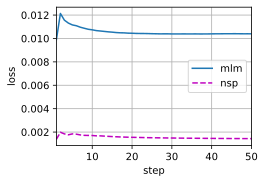

In [8]:
devices = spy.try_all_gpus()
train_BERT(train_iter, net, loss, len(vocab), devices, 50)

## STEP 2 - Representing text with BERT

After pretraining BERT, we can use it to represent single text, text pairs, or any token in them. The following function returns the BERT (net) representations for all tokens in `tokens_a` and `tokens_b`.

In [23]:
def get_BERT_encoding(net, tokens_a, tokens_b=None):
    tokens, segments = spy.get_tokens_and_segments(tokens_a, tokens_b)
    token_ids = torch.tensor(vocab[tokens], device=devices[0]).unsqueeze(0)
    segments = torch.tensor(segments, device=devices[0]).unsqueeze(0)
    valid_lens = torch.tensor(len(tokens), device=devices[0]).unsqueeze(0)
    encoded_X, _, _ = net(token_ids, segments, valid_lens)
    return encoded_X

Consider the sentence `a crane is flying`. After inserting special tokens `<cls>` (used for classification) and `<sep>` (used for separation), the BERT input sequence has a length of six. Since zero is the index of the `<cls>` token, encoded_text[:, 0, :] is the BERT representation of the entire input sentence. To evaluate the polysemy token `crane`, we also print out the first three elements of the BERT representation of the token.

In [28]:
tokens_a = ['a', 'crane', 'is', 'flying']
encoded_text = get_BERT_encoding(net, tokens_a)
# Tokens: '<cls>', 'a', 'crane', 'is', 'flying', '<sep>'
encoded_cls = encoded_text[:, 0, :]
encoded_crane = encoded_text[:, 2, :]
print(encoded_text.shape)
print(encoded_text[0, :, :3])
print(encoded_cls.shape)
print(encoded_crane.shape)
print(encoded_cls[0, :5])

torch.Size([1, 6, 128])
tensor([[-0.6807,  0.6962,  0.1851],
        [-0.8227,  1.0904, -1.5729],
        [-0.7128,  0.5928,  0.1417],
        [-0.7895,  0.6218,  0.1112],
        [-0.8414,  0.6682,  0.1750],
        [-0.0490,  0.5386, -0.0309]], grad_fn=<SliceBackward0>)
torch.Size([1, 128])
torch.Size([1, 128])
tensor([-0.6807,  0.6962,  0.1851,  0.6457,  2.6369], grad_fn=<SliceBackward0>)


Now consider a sentence pair `a crane driver came` and `he just left`. Similarly, `encoded_pair[:, 0, :]` is the encoded result of the entire sentence pair from the pretrained BERT. Note that the first three elements of the polysemy token `crane` are different from those when the context is different. This supports that BERT representations are context-sensitive.

In [29]:
tokens_a, tokens_b = ['a', 'crane', 'drive', 'came'], ['he', 'just', 'left']
encoded_pair = get_BERT_encoding(net, tokens_a, tokens_b)
encoded_pair_cls = encoded_pair[:, 0, :]
encoded_pair_crane = encoded_pair[:, 2, :]
print(encoded_pair.shape)
print(encoded_pair_cls.shape)
print(encoded_pair_crane.shape)
print(encoded_pair_cls[0, :5])

torch.Size([1, 10, 128])
torch.Size([1, 128])
torch.Size([1, 128])
tensor([-0.0674,  0.5885,  0.0701,  0.4942,  2.5635], grad_fn=<SliceBackward0>)
